### Output Parser


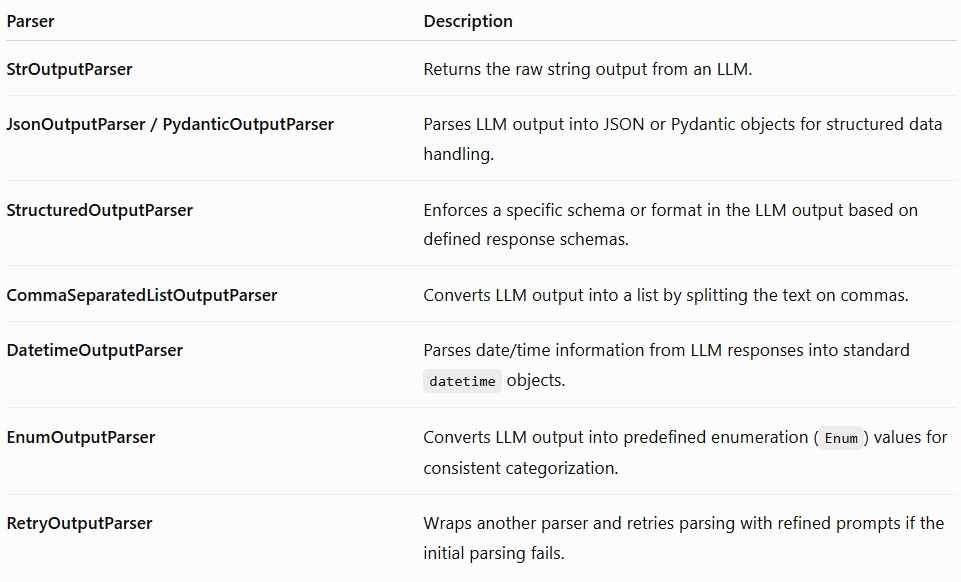

This code is same as the module 1 code  (due to Api limit just change from Gemini to Groq)  , by using this we will se how Output parser Will helps

Incase any error arrise in this Module is completely on Langchain library , langchain frequently change their library locations , so in redirecting on import statement may arrise error (To rectify from this error just refer import library format from langchain)

In [3]:
"""
import langchain
import os 
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
load_dotenv()
google_api_key=os.getenv("GOOGLE_API_KEY")
llm=ChatGoogleGenerativeAI(google_api_key=google_api_key, model="Gemini 2.5 Flash-Lite", temperature=0.2)
'''
res=llm.invoke("what is Lang chain?")
print(res.content)
'''
prompt=PromptTemplate(
    input_variables=["input"], 
    template="you are helpful assistant. Answer the following question:{input}"
)
chain=prompt | llm
res =chain.invoke({"input":"what is Lang chain? in one line"})
print(res)

"""

'\nimport langchain\nimport os \nfrom dotenv import load_dotenv\nfrom langchain_google_genai import ChatGoogleGenerativeAI\nfrom langchain_core.prompts import PromptTemplate\nload_dotenv()\ngoogle_api_key=os.getenv("GOOGLE_API_KEY")\nllm=ChatGoogleGenerativeAI(google_api_key=google_api_key, model="Gemini 2.5 Flash-Lite", temperature=0.2)\n\'\'\'\nres=llm.invoke("what is Lang chain?")\nprint(res.content)\n\'\'\'\nprompt=PromptTemplate(\n    input_variables=["input"], \n    template="you are helpful assistant. Answer the following question:{input}"\n)\nchain=prompt | llm\nres =chain.invoke({"input":"what is Lang chain? in one line"})\nprint(res)\n\n'

In [5]:
import langchain
import os

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    groq_api_key=groq_api_key,
    model="openai/gpt-oss-120b",
    temperature=0.2
)

'''
res = llm.invoke("What is LangChain?")
print(res.content)
'''

prompt = PromptTemplate(
    input_variables=["input"],
    template="You are a helpful assistant. Answer the following question: {input}"
)

chain = prompt | llm

res = chain.invoke({
    "input": "What is LangChain? in one line"
})

print(res.content)

LangChain is a framework for building applications that combine large language models with external data sources, tools, and custom logic.


In above code the output contant result along with it , it have meta data .
while using " .content "  by only we get the result , but that is not a proper and correct approach.

For that we use Output Parser

In [10]:
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template(
    "give me a brief summary in 1 line about this topic:{topic}"
)

chain = prompt | llm | StrOutputParser()

result=chain.invoke({"topic":"Output parsers"})
print(result)

#print(result.__class__)

Output parsers transform the raw text output of a language model into a structured, usable format (e.g., JSON, lists, objects).


#### Json Output parser  - Ex1

In [ ]:
#partial variables

template =PromptTemplate.from_template(
    "Hello {name}, today is {date}" ,
    partial_variables={"date":"2026-07-25"} #pre-filling the date variable
)

In [22]:
from langchain_core.output_parsers import JsonOutputParser

json_parser=JsonOutputParser()

prompt=PromptTemplate.from_template(
    """ Give me info about this celebrity :{celebrity_name} . I want name , age and date of birth.
    \n{format_instructions} """,
    partial_variables={"format_instructions":json_parser.get_format_instructions()} 
)   

#try 1

# prompt.format(celebrity_name="Vijay")


# try 2  (while not include parser in the chain but it still return in unstructured format)

# chain= prompt | llm 
# chain.invoke({"celebrity_name":"Vijay"})


#try 3 (original proper method)

chain= prompt | llm |json_parser
chain.invoke({"celebrity_name":"Vijay"})


{'name': 'Joseph Vijay Chandrasekhar',
 'age': 49,
 'date_of_birth': '1974-06-22'}

#### Json Output parser  - Ex2

instead of defining parser in prompt , we operate it with Model by using **pydantic**   

pydantic is python library , used to defining schema and also used in validating output

eg:
in Ex 1 : once we simply run the  get_format_instructions() it gives Return a JSON Object

but here it return a schema and model refer it and return the result

In [29]:
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel , Field


# easy to uderstand and structured output using pydantic model  (for  leaning purpose)

class person(BaseModel):
    name : str=Field(description="Name of the person")
    age : str=Field(description="Age of the person")
    date_of_birth : str=Field(description="Date of birth of the person")
    place_of_birth : str=Field(description="Place of birth of the person")

# Little advanced way to use pydantic model with json output parser  (for  leaning purpose)
'''
class BirthInfo(BaseModel):
    birth_date: str = Field(description="Date of birth of the person")
    place_of_birth: str = Field(description="Place of birth")

class Person(BaseModel):
    name: str = Field(description="Name of the person")
    age: str = Field(description="Age of the person")
    birth_info: BirthInfo = Field(description="Birth information")
'''

json_parser=JsonOutputParser(pydantic_object=person)

# json_parsr.get_format_instructions()

prompt=PromptTemplate.from_template(
    """ Give me info about this celebrity :{celebrity_name} \n{format_instructions}""",
    partial_variables={"format_instructions":json_parser.get_format_instructions()}
)

chain= prompt | llm | json_parser
chain.invoke({"celebrity_name":"Vijay"}) 

# chain.invoke({"celebrity_name":"Vijay"}) .__class__

{'name': 'Joseph Vijay Chandrasekhar',
 'age': '49',
 'date_of_birth': 'June 22, 1974',
 'place_of_birth': 'Chennai, Tamil Nadu, India'}

### Pydantic Output Parser

In [33]:
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel , Field


class person(BaseModel):
    name : str=Field(description="Name of the person")
    age : str=Field(description="Age of the person")
    date_of_birth : str=Field(description="Date of birth of the person")
    place_of_birth : str=Field(description="Place of birth of the person")


pydantic_parser=PydanticOutputParser(pydantic_object=person)

# json_parsr.get_format_instructions()

prompt=PromptTemplate.from_template(
    """ Give me info about this celebrity :{celebrity_name} \n{format_instructions}""",
    partial_variables={"format_instructions":pydantic_parser.get_format_instructions()}
)

chain= prompt | llm | pydantic_parser


chain.invoke({"celebrity_name":"Vijay"}) 

#chain.invoke({"celebrity_name":"Vijay"}) .date_of_birth

person(name='Joseph Vijay Chandrasekhar', age='50', date_of_birth='June 22, 1974', place_of_birth='Chennai, Tamil Nadu, India')

### Structure Output Parser

In [ ]:

from langchain_core.output_parsers import ResponseSchema, StructuredOutputParser


response_schemas = [
    ResponseSchema(name="name", description="name of the person"),
    ResponseSchema(name="age", description="age of the person"),
    ResponseSchema(name="birth_date", description="birth date of the person")
]

structured_parser = StructuredOutputParser.from_response_schemas(response_schemas)

# structured_parser.get_format_instructions()

prompt = PromptTemplate.from_template(
    """Give me name, age and date of birth in dd/mm/yyyy format for this celebrity: {celebrity_name}
    \n{format_instructions}""",
    partial_variables={"format_instructions": structured_parser.get_format_instructions()}
)

# prompt.format(celebrity_name="Elon Musk")

chain = prompt | google_llm | structured_parser

chain.invoke({"celebrity_name": "Elon Musk"})


### CommaSeperatedList Output Parser


In [7]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser

parser=CommaSeparatedListOutputParser()

prompt=PromptTemplate.from_template(
    """Give me name , age, and birth in dd/mm/yyyy format for this celebrity : {celebrity_name}
    \n{format_instructions}""",
    partial_variables={"format_instructions": parser.get_format_instructions()}
)

chain=prompt | llm| parser

chain.invoke({"celebrity_name":"APJ"})

['A.P.J. Abdul Kalam', '83', '15/10/1931']

### DateTime Output parser

In [ ]:
from langchain.output_parsers.datetime import DatetimeOutputParser
from datetime import datetime

datetime_parser = DatetimeOutputParser()

# print(datetime_parser.get_format_instructions())

prompt = PromptTemplate.from_template(
"""Give me date of birth: {celebrity_name}. Output only the date time and nothing else.
\n {format_instructions}""",
partial_variables={"format_instructions":datetime_parser.get_format_instructions()}
)

prompt.format(celebrity_name="Elon Musk")

chain = prompt | google_llm | datetime_parser

res = chain.invoke({"celebrity_name": "Elon Musk"})

print(res)

# print(res.strftime("%Y-%m-%d"))  # 👉 1971-06-28
# print(res.strftime("%B %d, %Y"))  # 👉 June 28, 1971


### Enum Output parser

In [ ]:
from langchain.output_parsers.enum import EnumOutputParser
from enum import Enum

class YesNoMaybe(Enum):
    YES = "yes"
    NO = "no"
    MAYBE = "maybe"

enum_parser = EnumOutputParser(enum=YesNoMaybe)

# print(enum_parser.get_format_instructions())

prompt = PromptTemplate.from_template(
    "Is {celebrity_name} an actor?. \n Format instructions: {format_instructions}. " \
    "Always stick to the format instructions cases in the response",
    partial_variables={"format_instructions":enum_parser.get_format_instructions()}
)

chain = prompt | google_llm | enum_parser

res = chain.invoke({"celebrity_name": "Elon musk"})

print("No") if res is YesNoMaybe.NO else None
print("Yes") if res is YesNoMaybe.YES else None


### Retry Output Parser

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain.output_parsers.enum import EnumOutputParser
from langchain.output_parsers.retry import RetryOutputParser
from langchain_core.runnables import RunnableLambda, RunnableParallel
from enum import Enum
from langchain_core.messages import AIMessage

class YesNoMaybe(Enum):
    YES = "yes"
    NO = "no"
    MAYBE = "maybe"

enum_parser = EnumOutputParser(enum=YesNoMaybe)
retry_parser = RetryOutputParser.from_llm(parser=enum_parser, llm=google_llm, max_retries=2)

# print(retry_parser.get_format_instructions())

prompt = PromptTemplate.from_template(
    "Is {celebrity_name} an actor?. \n Format instructions: {format_instructions}. " \
    "Always stick to the format instructions cases in the response",
    partial_variables={"format_instructions": enum_parser.get_format_instructions()}
)

# prompt.format(celebrity_name="Elon Musk")
